<a href="https://colab.research.google.com/github/vishwesh-V/virtue-of-complexity/blob/main/kmz/kmz_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


(1860, 57)
['yyyymm', 'price', 'd12', 'e12', 'ret', 'retx', 'AAA', 'BAA', 'lty', 'ltr', 'corpr', 'tbl', 'Rfree', 'd/p', 'd/y', 'e/p', 'd/e', 'b/m', 'tms', 'dfy', 'dfr', 'infl', 'eqis', 'ntis', 'svar', 'cay', 'i/k', 'csp', 'pce', 'vp', 'impvar', 'vrp', 'govik', 'lzrt', 'skew', 'crdstd', 'ogap', 'wtexas', 'accrul', 'cfacc', 'sntm', 'ndrbl', 'skvw', 'tail', 'fbm', 'dtoy', 'dtoat', 'ygap', 'rdsp', 'rsvix', 'gpce', 'gip', 'tchi', 'house', 'avgcor', 'shtint', 'disag']
                                date           dp           dy           ep  \
count                           1860  1860.000000  1859.000000  1860.000000   
mean   1948-06-16 06:31:44.516129024     0.042203     0.042292     0.072079   
min              1871-01-01 00:00:00     0.010849     0.010771     0.007935   
25%              1909-09-23 12:00:00     0.029897     0.030012     0.053715   
50%              1948-06-16 00:00:00     0.041964     0.042069     0.066484   
75%              1987-03-08 18:00:00     0.053335     0.053

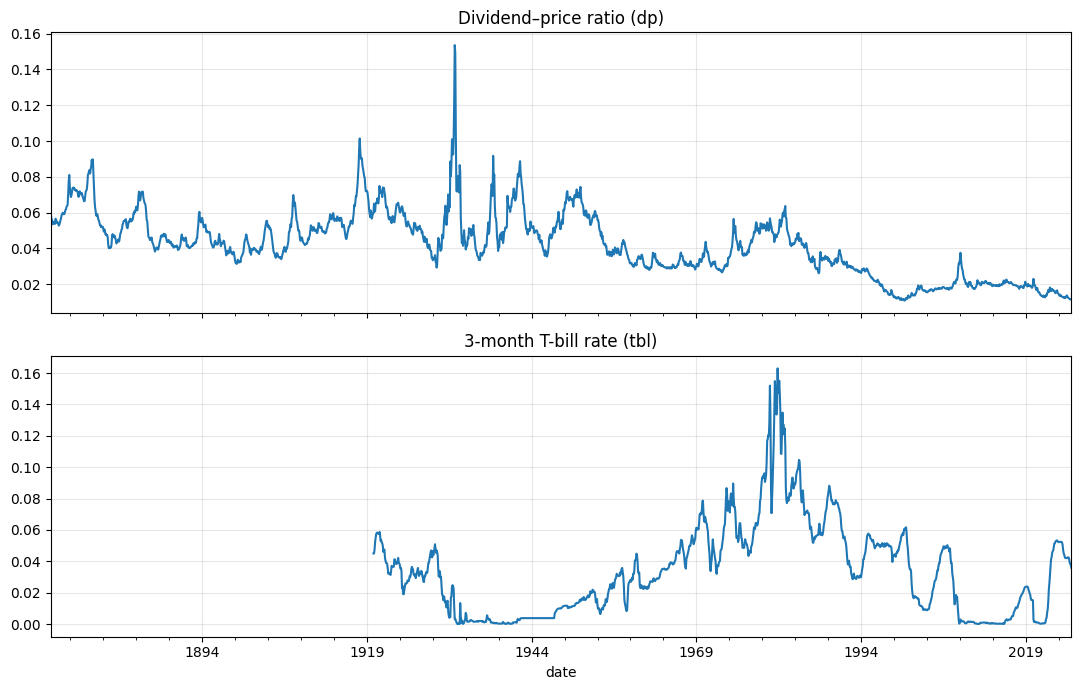

saved (1189, 17) 1926-12-01 00:00:00 → 2025-12-01 00:00:00


In [11]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd, numpy as np, matplotlib.pyplot as plt

KMZ = "/content/drive/MyDrive/Summer Research/kmz"
goyal_welch = pd.read_excel(f"{KMZ}/Data2025.xlsx", sheet_name="Monthly")
print(goyal_welch.shape)
print(goyal_welch.columns.tolist())
goyal_welch.head()

# rename slashed columns to clean names
gw = goyal_welch.rename(columns={
    "d/p":"dp", "d/y":"dy", "e/p":"ep", "d/e":"de", "b/m":"bm"
}).copy()

gw["date"] = pd.to_datetime(gw["yyyymm"].astype(int).astype(str), format="%Y%m")
gw = gw.sort_values("date").reset_index(drop=True)

# the 15th predictor: lagged market return
gw["mktret_lag"] = gw["ret"].shift(1)

# target: monthly log excess return (KMZ predict this)
gw["excess_ret"] = np.log(1 + gw["ret"]) - np.log(1 + gw["Rfree"])

predictors = ["dp","dy","ep","de","svar","bm","ntis","tbl","lty","ltr",
              "tms","dfy","dfr","infl","mktret_lag"]

assert len(predictors) == 15

# clean panel to save
print(gw[["date"] + predictors].describe())
print("\nfirst valid rows:")
print(gw[["date"] + predictors].dropna().head(3))

# sanity plots
fig, ax = plt.subplots(2,1, figsize=(11,7), sharex=True)
gw.set_index("date")["dp"].plot(ax=ax[0], title="Dividend–price ratio (dp)"); ax[0].grid(alpha=.3)
gw.set_index("date")["tbl"].plot(ax=ax[1], title="3-month T-bill rate (tbl)"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()


# saving cleaned data
panel = gw[["date"] + predictors + ["excess_ret"]].dropna().reset_index(drop=True)
panel.to_parquet(f"{KMZ}/predictors.parquet")
print("saved", panel.shape, panel["date"].min(), "→", panel["date"].max())